In [1]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# 1. 기본 설정

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

DATA_DIR = "./datasets/imagenette2-160"
BATCH_SIZE = 64
EPOCHS = 30
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
NUM_CLASSES = 10
IMG_SIZE = 224

Device: cuda


# 2. Imagenette 다운로드

In [3]:
!mkdir -p datasets
!wget -nc https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz -P datasets
!tar -xzf datasets/imagenette2-160.tgz -C datasets


--2026-06-17 06:27:36--  https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.213.240, 52.217.143.48, 16.15.229.25, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.213.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99003388 (94M) [application/x-tar]
Saving to: ‘datasets/imagenette2-160.tgz’

imagenette2-160.tgz 100%[===================>]  94.42M  35.9MB/s    in 2.6s    

2026-06-17 06:27:39 (35.9 MB/s) - ‘datasets/imagenette2-160.tgz’ saved [99003388/99003388]



# 3. Transform 정의

In [4]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform_no_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# 4. Dataset / DataLoader 함수

In [5]:
def make_dataloaders(use_aug=False):
    train_transform = train_transform_aug if use_aug else train_transform_no_aug

    train_dataset = datasets.ImageFolder(
        root=os.path.join(DATA_DIR, "train"),
        transform=train_transform
    )

    val_dataset = datasets.ImageFolder(
        root=os.path.join(DATA_DIR, "val"),
        transform=val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return train_loader, val_loader, train_dataset.classes

# 5. VGG 모델 생성 함수

In [6]:
def get_vgg_model(model_name):
    if model_name == "vgg11":
        model = models.vgg11(weights=None)
    elif model_name == "vgg16":
        model = models.vgg16(weights=None)
    elif model_name == "vgg19":
        model = models.vgg19(weights=None)
    else:
        raise ValueError("model_name must be vgg11, vgg16, or vgg19")

    # ImageNet 1000-class classifier를 Imagenette 10-class로 변경
    model.classifier[6] = nn.Linear(4096, NUM_CLASSES)
    return model

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 6. train / evaluate 함수


In [7]:
def train_one_model(model_name, use_aug=False):
    train_loader, val_loader, classes = make_dataloaders(use_aug=use_aug)

    model = get_vgg_model(model_name).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.1,
        patience=5
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    total_start = time.time()

    for epoch in range(EPOCHS):
        epoch_start = time.time()

        # ---------- train ----------
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc = train_correct / train_total

        # ---------- validation ----------
        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        scheduler.step(val_acc)

        epoch_time = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"[{model_name} | aug={use_aug}] "
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )

    total_time = time.time() - total_start

    model.load_state_dict(best_model_wts)

    result = {
        "model": model_name,
        "augmentation": use_aug,
        "best_val_acc": best_acc,
        "avg_epoch_time_sec": sum(history["epoch_time"]) / len(history["epoch_time"]),
        "total_time_sec": total_time,
        "parameters": count_parameters(model),
        "history": history
    }

    return result

# 7. 실험 1: 깊이 비교
데이터 증강 없이 VGG11, VGG16, VGG19를 비교함


In [8]:
results_depth = []

for model_name in ["vgg11", "vgg16", "vgg19"]:
    result = train_one_model(model_name, use_aug=False)
    results_depth.append(result)

summary_depth = pd.DataFrame([
    {
        "Model": r["model"],
        "Augmentation": r["augmentation"],
        "Best Val Accuracy": r["best_val_acc"],
        "Avg Epoch Time(sec)": r["avg_epoch_time_sec"],
        "Total Time(sec)": r["total_time_sec"],
        "Parameters": r["parameters"]
    }
    for r in results_depth
])

summary_depth

[vgg11 | aug=False] Epoch 1/30 | Train Loss: 2.1011 | Train Acc: 0.2325 | Val Acc: 0.3618 | Time: 17.6s
[vgg11 | aug=False] Epoch 2/30 | Train Loss: 1.7834 | Train Acc: 0.3863 | Val Acc: 0.3781 | Time: 16.4s
[vgg11 | aug=False] Epoch 3/30 | Train Loss: 1.5706 | Train Acc: 0.4691 | Val Acc: 0.5118 | Time: 17.3s
[vgg11 | aug=False] Epoch 4/30 | Train Loss: 1.3656 | Train Acc: 0.5456 | Val Acc: 0.5786 | Time: 17.3s
[vgg11 | aug=False] Epoch 5/30 | Train Loss: 1.1724 | Train Acc: 0.6127 | Val Acc: 0.5898 | Time: 17.2s
[vgg11 | aug=False] Epoch 6/30 | Train Loss: 0.9698 | Train Acc: 0.6820 | Val Acc: 0.6441 | Time: 17.0s
[vgg11 | aug=False] Epoch 7/30 | Train Loss: 0.8602 | Train Acc: 0.7173 | Val Acc: 0.6624 | Time: 17.2s
[vgg11 | aug=False] Epoch 8/30 | Train Loss: 0.7269 | Train Acc: 0.7625 | Val Acc: 0.6843 | Time: 17.2s
[vgg11 | aug=False] Epoch 9/30 | Train Loss: 0.6071 | Train Acc: 0.8021 | Val Acc: 0.6973 | Time: 17.0s
[vgg11 | aug=False] Epoch 10/30 | Train Loss: 0.4522 | Train Acc

,Model,Augmentation,Best Val Accuracy,Avg Epoch Time(sec),Total Time(sec),Parameters
0,vgg11,False,0.741401,16.844063,505.372040,128807306
1,vgg16,False,0.720255,21.947047,658.464627,134301514
2,vgg19,False,0.691975,24.282721,728.539749,139611210


- 검증 정확도의 변화: 30 epoch 기준으로는 VGG11이 약 74.8%로 가장 높은 검증 정확도를 보였다. VGG16은 약 71.5%로 VGG11과 차이가 크지는 않지만, VGG19는 약 70.6%로 상대적으로 낮았다.
따라서 이 결과만 보면 CNN의 깊이가 깊어질수록 성능이 계속 향상된다고 말하기 어렵다. 오히려 Imagenette 데이터셋과 30 epoch 조건에서는 VGG11이 가장 효율적인 모델로 나타났다.
즉, VGG16은 더 깊은 모델이지만 30 epoch 안에서는 VGG11을 넘지 못했고, 더 긴 학습이 필요할 가능성이 있다.

- 학습 시간의 변화: 깊이가 깊어질수록 확실히 증가했다. VGG16은 VGG11보다, VGG19는 VGG16보다 오래 걸렸다. 그런데 정확도는 VGG11이 가장 높았다.
깊은 모델일수록 계산 비용은 증가했지만, 30 epoch 조건에서는 그에 비례하는 성능 향상은 나타나지 않았다.

- 결과 해석
1. 30 epoch가 VGG19가 충분히 수렴하기에는 부족했을 수 있다.
2. Imagenette는 비교적 작은 데이터셋이므로 깊은 모델이 장점을 충분히 발휘하지 못했을 수 있다.

# 9. Loss Curve


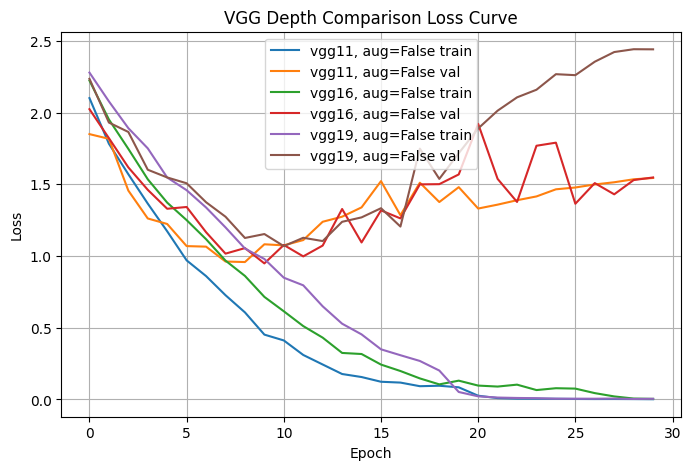

In [10]:
def plot_loss_curve(results, title):
    plt.figure(figsize=(8, 5))

    for r in results:
        label = f"{r['model']}, aug={r['augmentation']}"
        plt.plot(r["history"]["train_loss"], label=f"{label} train")
        plt.plot(r["history"]["val_loss"], label=f"{label} val")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curve(results_depth, "VGG Depth Comparison Loss Curve")

#10. Accuracy curve

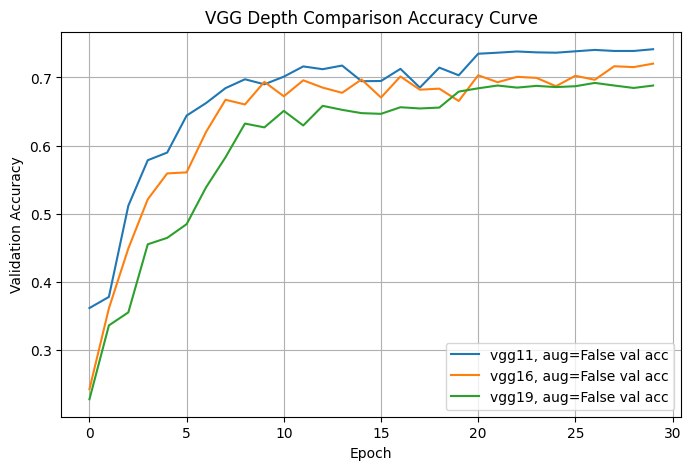

In [11]:
def plot_acc_curve(results, title):
    plt.figure(figsize=(8, 5))

    for r in results:
        label = f"{r['model']}, aug={r['augmentation']}"
        plt.plot(r["history"]["val_acc"], label=f"{label} val acc")

    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_acc_curve(results_depth, "VGG Depth Comparison Accuracy Curve")